In [1]:
import sys

sys.path.append("../")

import scipy
import optuna

import numpy as np
import pandas as pd

from docplex.mp.model import Model
from qiskit.circuit import ClassicalRegister, ParameterVector, QuantumCircuit, QuantumRegister
from qiskit.primitives import BackendEstimatorV2
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit_addon_opt_mapper.converters import OptimizationProblemToQubo
from qiskit_addon_opt_mapper.translators import from_docplex_mp
from qiskit_aer import AerSimulator

from dicke_state_ansatz import DickeStateAnsatz
from utils import objective_scipy, ObjectiveOptuna

/home/jvictor/coding/python/quantum-optimization-dicke-states/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
simulator = AerSimulator(method="statevector", device="CPU")
estimator = BackendEstimatorV2(backend=simulator)
pm = generate_preset_pass_manager(backend=simulator, optimization_level=0)

In [3]:
assets_data = pd.read_csv(filepath_or_buffer="../datasets/sp500_assets_close_price.csv", index_col=0)

In [4]:
np.random.seed(seed=42)
tickers = np.random.choice(assets_data.columns, size=11, replace=False)
assets_close_price = assets_data[tickers]

In [5]:
assets_pct_change = assets_close_price.pct_change().dropna()

In [6]:
covariance_annualized = assets_pct_change.cov()*np.sqrt(252)
returns_annualized = assets_pct_change.mean()*252

In [7]:
q = 0.5
b = 4
return_risk_free = 0.0375

In [8]:
sum([scipy.special.comb(11,i) for i in range(1,5)])

np.float64(561.0)

In [9]:
model = Model(name="combinatorial_portfolio_optimization")
x = np.array([model.binary_var(name=f"x({i})") for i in range(len(tickers))])
model.minimize(q*(x.T@covariance_annualized.values@x)-(1-q)*(returns_annualized.values@x)+return_risk_free)
model.add_constraint(x.sum() <= b)
print(model.prettyprint())

// This file has been generated by DOcplex
// model name is: combinatorial_portfolio_optimization
// single vars section
dvar bool x(0);
dvar bool x(1);
dvar bool x(2);
dvar bool x(3);
dvar bool x(4);
dvar bool x(5);
dvar bool x(6);
dvar bool x(7);
dvar bool x(8);
dvar bool x(9);
dvar bool x(10);

minimize
 - 0.073237 x(0) + 0.006494 x(1) - 0.050421 x(2) - 0.029112 x(3)
 - 0.257503 x(4) - 0.041122 x(5) + 0.223546 x(6) - 0.018526 x(7)
 - 0.049584 x(8) - 0.420045 x(9) - 0.274106 x(10) [ 0.005641 x(0)^2
 - 0.000466 x(0)*x(1) + 0.000173 x(0)*x(2) + 0.000529 x(0)*x(3)
 + 0.001116 x(0)*x(4) + 0.000100 x(0)*x(5) + 0.001793 x(0)*x(6)
 + 0.000590 x(0)*x(7) - 0.000777 x(0)*x(8) + 0.001088 x(0)*x(9)
 + 0.001330 x(0)*x(10) + 0.001649 x(1)^2 + 0.000596 x(1)*x(2)
 + 0.000354 x(1)*x(3) + 0.000791 x(1)*x(4) + 0.000433 x(1)*x(5)
 + 0.001388 x(1)*x(6) + 0.000959 x(1)*x(7) + 0.000498 x(1)*x(8)
 + 0.000738 x(1)*x(9) + 0.000093 x(1)*x(10) + 0.001870 x(2)^2
 + 0.001690 x(2)*x(3) + 0.001926 x(2)*x(4) + 0.001

In [10]:
result = model.solve()

In [11]:
result.objective_value

-0.9637330124062767

In [12]:
result_array = np.array([result.get_value(f"x({i})") for i in range(assets_close_price.columns.shape[0])])

In [13]:
result_array

array([1., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1.])

In [14]:
target = result_array.astype(int)
target = ""
for item in result_array.astype(int):
    target += str(item)
target = target[::-1]

In [15]:
target

'11000010001'

In [16]:
model = Model(name="combinatorial_portfolio_optimization")
x = np.array([model.binary_var(name=f"x({i})") for i in range(len(tickers))])
model.minimize(q*(x.T@covariance_annualized.values@x)-(1-q)*(returns_annualized.values@x)+return_risk_free)
quad_model = from_docplex_mp(model=model)
qubo_converter = OptimizationProblemToQubo(penalty=1e-12)
qubo = qubo_converter.convert(quad_model)
ising, offset = qubo.to_ising()

In [17]:
identity = SparsePauliOp(data="II", coeffs=[1])
ising_expanded = ising.tensor(other=identity)

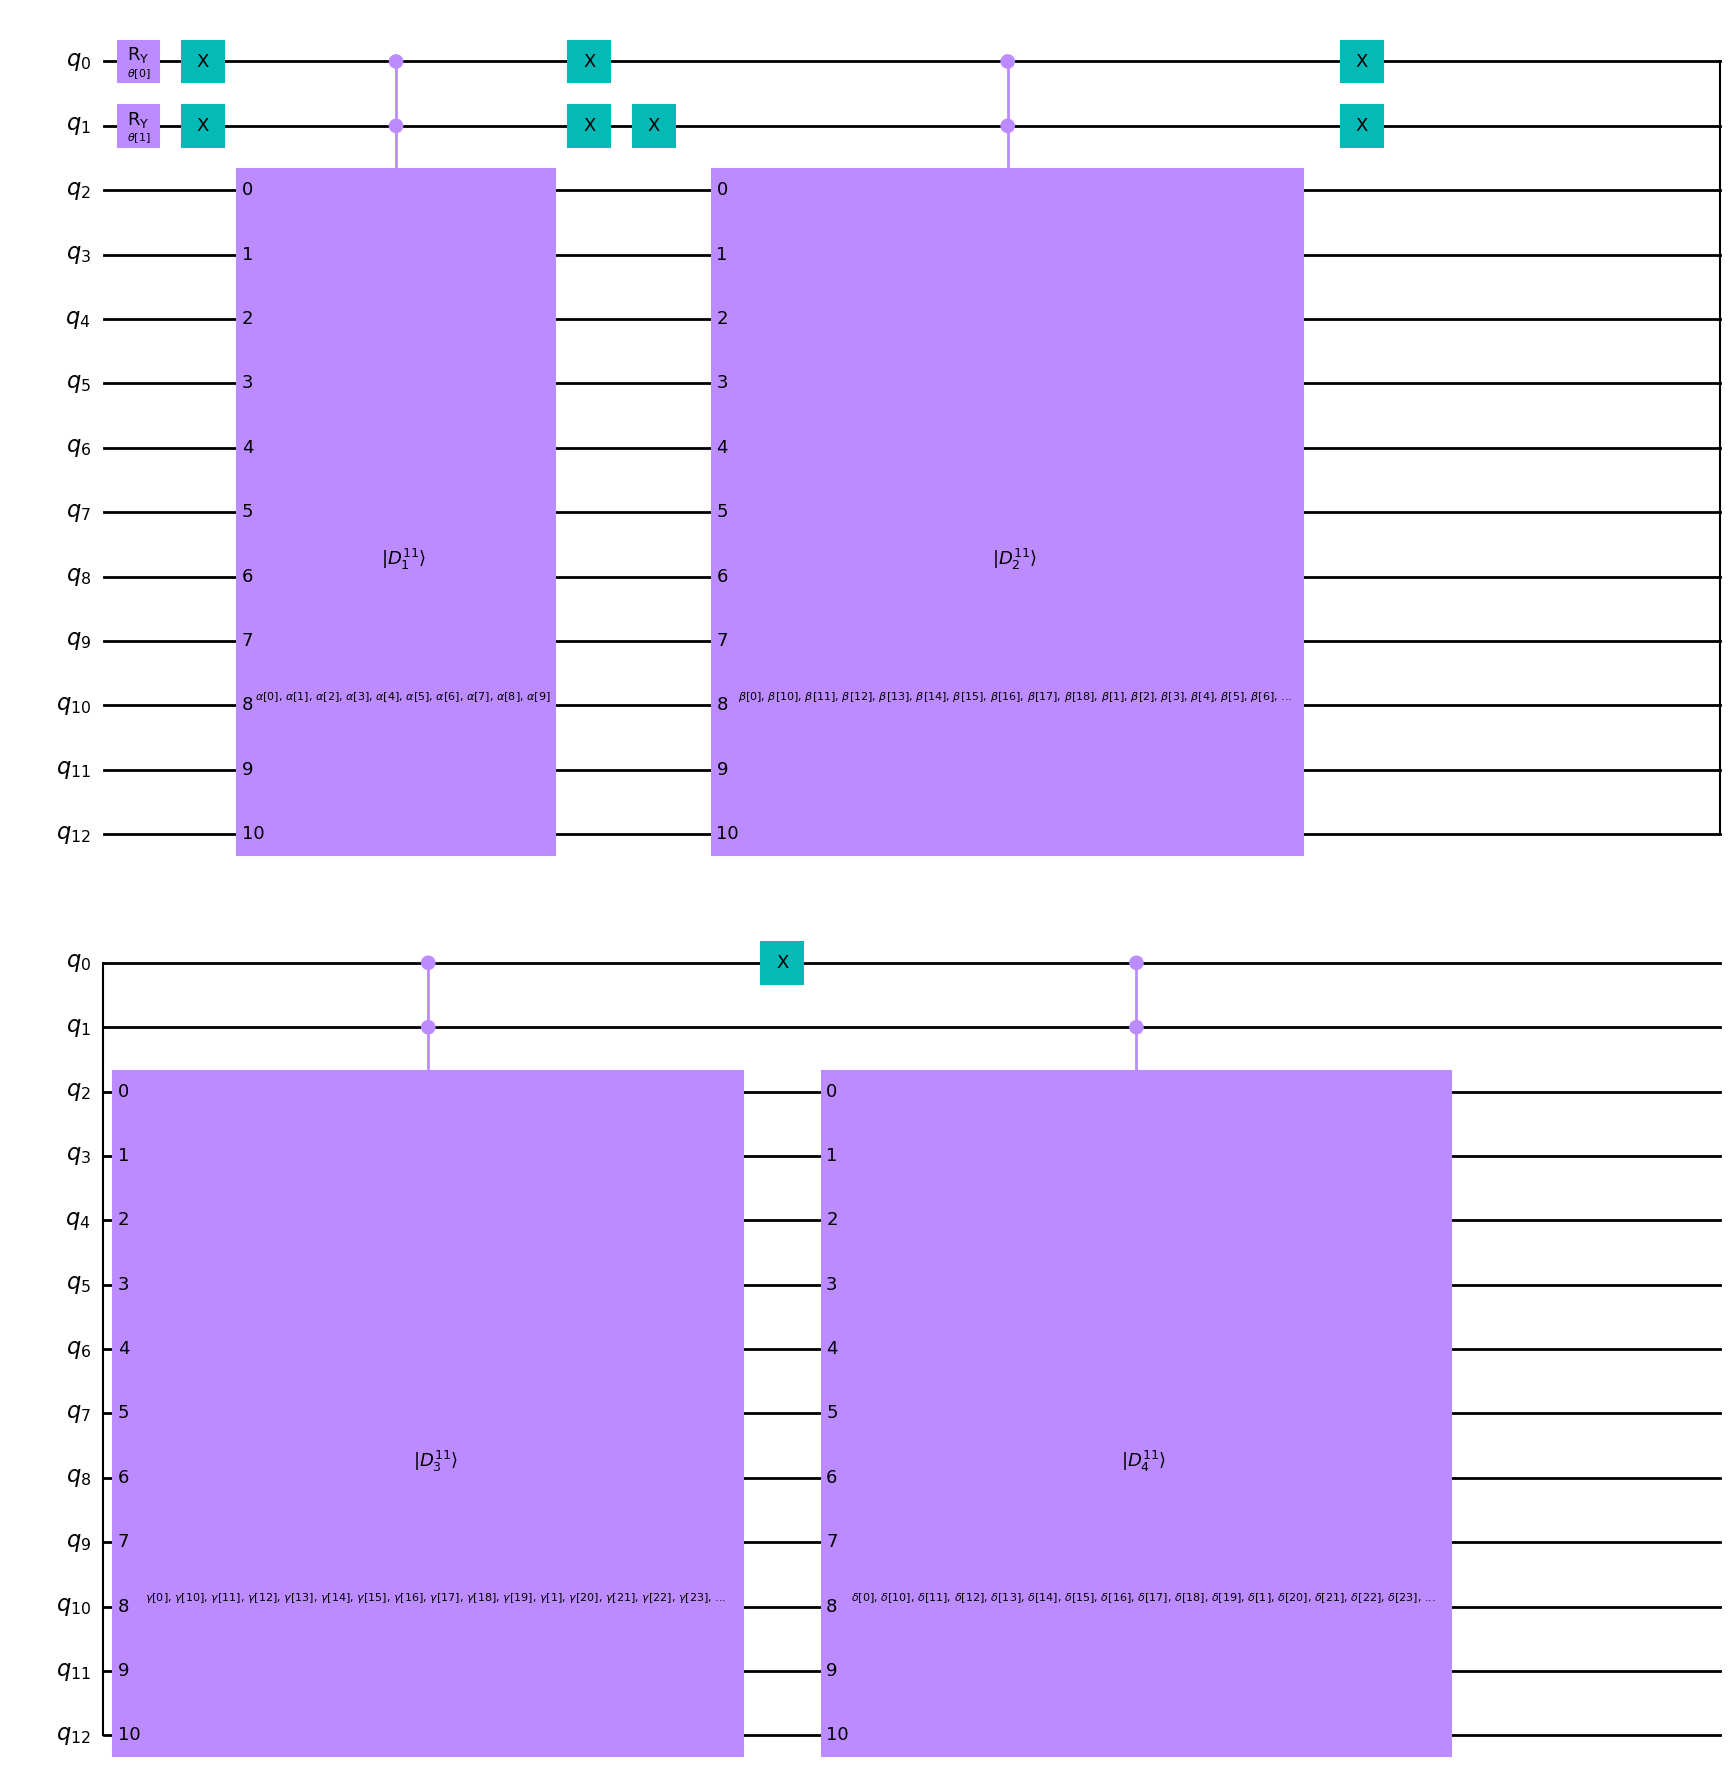

In [18]:
qubits = QuantumRegister(size=ising_expanded.num_qubits, name="q")
params_vec = ParameterVector(name=r"$\theta$", length=ising_expanded.num_qubits-ising.num_qubits)

qc = QuantumCircuit(qubits)
for idx, param in enumerate(params_vec):
    qc.ry(theta=param, qubit=qubits[idx])

params_names = {1: "alpha", 2: "beta", 3: "gamma", 4: "delta"}
gate_name = {
    1: r"$\vert D^{11}_{1} \rangle$",
    2: r"$\vert D^{11}_{2} \rangle$",
    3: r"$\vert D^{11}_{3} \rangle$",
    4: r"$\vert D^{11}_{4} \rangle$",
}

for k in range(1,5):
    dicke = DickeStateAnsatz().generate_quantum_circuit(n=len(tickers), k=k, measurement=False, param_name=params_names[k])
    if k == 1:
        qc.x(qubit=qubits[[i for i in range(ising_expanded.num_qubits-ising.num_qubits)]])
    elif k == 2:
        qc.x(qubit=qubits[1])
    elif k == 3:
        qc.x(qubit=qubits[0])
    dicke_gate = dicke.to_gate(label=gate_name[k]).control(2)
    qc.append(dicke_gate, qargs=range(qubits.size))
    if k == 1:
        qc.x(qubit=qubits[[i for i in range(ising_expanded.num_qubits-ising.num_qubits)]])
    elif k == 2:
        qc.x(qubit=qubits[1])
    elif k == 3:
        qc.x(qubit=qubits[0])

qc.draw(output="mpl", style="clifford")

In [19]:
tqc = pm.run(qc)

In [32]:
x0 = 2*np.pi*np.random.random(size=qc.num_parameters)
bounds = [(0, 2*np.pi) for _ in range(x0.shape[0])]
result = scipy.optimize.minimize(fun=objective_scipy, x0=x0, method="cobyqa", bounds=bounds, args=(estimator, tqc, ising_expanded, offset))

In [33]:
result

 message: The lower bound for the trust-region radius has been reached
 success: True
  status: 0
     fun: -0.9621791516839647
       x: [ 5.279e+00  9.478e-01 ...  3.128e+00  3.160e+00]
     nit: 880
   maxcv: 0.0
    nfev: 1903

In [34]:
bits = ClassicalRegister(size=ising.num_qubits)
ansatz = tqc.copy()
params_mapper = {param: value for param, value in zip(ansatz.parameters, result.x)}
ansatz = ansatz.assign_parameters(parameters=params_mapper)
ansatz.add_register(bits)
ansatz.measure(qubit=ansatz.qregs[0][ising_expanded.num_qubits-ising.num_qubits:], cbit=bits)

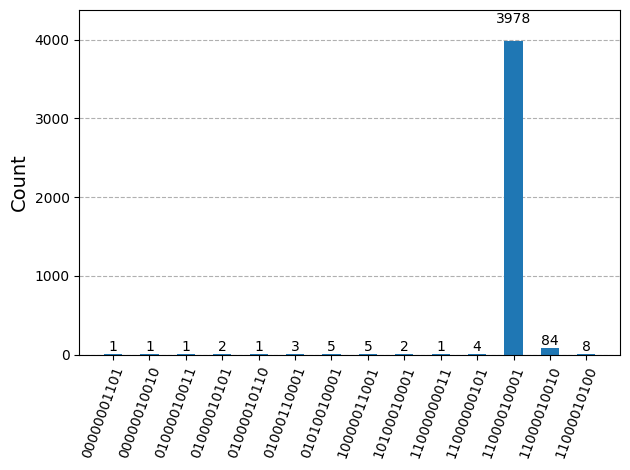

In [35]:
counts = simulator.run(circuits=ansatz, shots=4096).result().get_counts()
plot_histogram(data=counts)

In [36]:
counts[target]

3978

In [37]:
objective_optuna = ObjectiveOptuna(qc=tqc, estimator=estimator, ising=ising_expanded, offset=offset, callback=None)

In [38]:
x0_dict = {f"x[{i}]": value for i, value in enumerate(x0)}

In [39]:
sampler = optuna.samplers.CmaEsSampler(x0=x0_dict, use_separable_cma=True)
study = optuna.create_study(sampler=sampler)
study.optimize(objective_optuna, n_trials=1000)

/home/jvictor/coding/python/quantum-optimization-dicke-states/env/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``use_separable_cma`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-05-13 18:57:08,242] A new study created in memory with name: no-name-f484e47c-60a1-492e-9d07-54f2e56ddee4
[I 2026-05-13 18:57:08,314] Trial 0 finished with value: 0.037727045979768614 and parameters: {'x[0]': 4.531873361009066, 'x[1]': 3.4098703718168206, 'x[2]': 3.691060370571344, 'x[3]': 0.376277816816592, 'x[4]': 4.750156518963913, 'x[5]': 5.877122719119801, 'x[6]': 4.318816584517895, 'x[7]': 4.13391959491326, 'x[8]': 3.5060337806014013, 'x[9]': 4.768897885228806, 'x[10]': 2.850943580214256, 'x[11]': 0.8297146189215072, 'x[12]': 2.988469480154189, 'x[13]': 2.2654832361681683, 'x[14]': 2.0466060183729957, 'x[15]': 3.9088143287604895, 'x[16]': 4.626268519538476, 'x[17]': 4.240271029968802, 'x[18]': 1.811147229788486, 'x[19]

In [40]:
study.best_value

-0.6584287339870526

In [44]:
bits = ClassicalRegister(size=ising.num_qubits)
ansatz = tqc.copy()
params_mapper = {param: value for param, value in zip(ansatz.parameters, study.best_params.values())}
ansatz = ansatz.assign_parameters(parameters=params_mapper)
ansatz.add_register(bits)
ansatz.measure(qubit=ansatz.qregs[0][ising_expanded.num_qubits-ising.num_qubits:], cbit=bits)

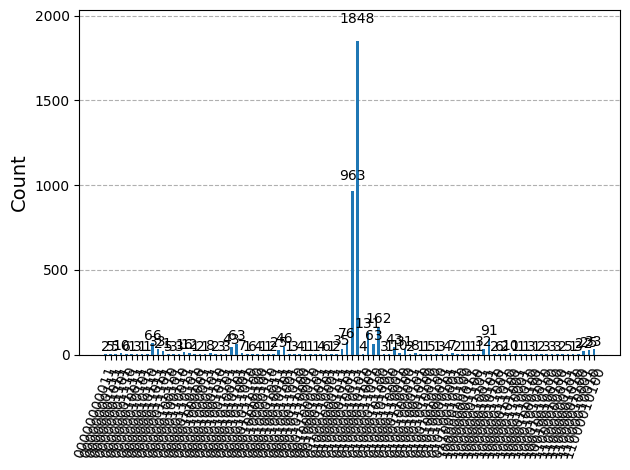

In [45]:
counts = simulator.run(circuits=ansatz, shots=4096).result().get_counts()
plot_histogram(data=counts)

In [46]:
counts[target]

22